# Reconstruction of a femtosecond laser written waveguide

This notebook shows how to reconstruct the cross-section of a longitudinally invariant waveguide from a 2D tomogram, which is a stack of intensity profiles recorded for different illumination angles.

The method used is the one described in the article [1]:

[1] *Nicolas Barré, Ravi Shivaraman, Lisa Ackermann, Simon Moser, Michael Schmidt, Patrick Salter, Martin Booth, and Alexander Jesacher. "Tomographic refractive index profiling of direct laser written waveguides." Optics Express 29, no. 22 (2021): 35414-35425.*

In [1]:
import Pkg

Pkg.add("FFTW")
Pkg.add("JLD")
Pkg.add("PyPlot")
Pkg.add("ProgressMeter")

using FFTW
using JLD
using PyPlot

FFTW.set_num_threads(4)

include("../../utils/julia/proximal_optim.jl")
include("../../utils/julia/model.jl")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\User\.julia\environments\v1.12\Manifest.toml`


get_aberration (generic function with 1 method)

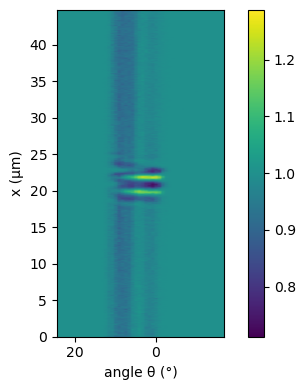

In [2]:
# we load the tomogram data which contains the intensity map I,
# the camera pixel pitch dx and the angle range θ_l in radians.

tomogram_data = load("./tomogram_guide.jld")
dx = tomogram_data["dx"]
I_map = tomogram_data["I"]
θ_l = tomogram_data["θ_l"];

figure(figsize=(5,4))
imshow(I_map, aspect=1.8, extent=[θ_l[1]*180/pi,θ_l[end]*180/pi, 0,dx*size(I_map,1)])
colorbar()
xlabel("angle θ (°)")
ylabel("x (μm)")
tight_layout()
display(gcf())

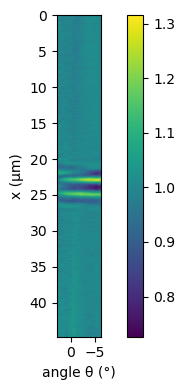

In [11]:
# We keep only a portion of the tomogram to avoid aberrations and recording issues at large angles.

l_i = 19:30
θ_l_i = θ_l[l_i] .- 0.11    # angles correction
I_map_i = I_map[:,l_i]
I_map_i .*= size(I_map_i, 1)./sum(I_map_i, dims=1)

nx = size(I_map_i, 1)

figure(figsize=(5.5,4))
imshow(I_map_i, aspect=1.5, extent=[θ_l_i[1]*180/pi,θ_l_i[end]*180/pi, nx*dx,0])
colorbar()
xlabel("angle θ (°)")
ylabel("x (μm)")
tight_layout()
display(gcf())

Progress:   7%|███                                      |  ETA: 0:00:17
Progress:  10%|█████                                    |  ETA: 0:00:15
Progress:  13%|██████                                   |  ETA: 0:00:14
Progress:  17%|███████                                  |  ETA: 0:00:13
Progress:  20%|█████████                                |  ETA: 0:00:12
Progress:  23%|██████████                               |  ETA: 0:00:12
Progress:  27%|███████████                              |  ETA: 0:00:11
Progress:  30%|█████████████                            |  ETA: 0:00:10
Progress:  33%|██████████████                           |  ETA: 0:00:10
Progress:  37%|████████████████                         |  ETA: 0:00:09
Progress:  40%|█████████████████                        |  ETA: 0:00:09
Progress:  43%|██████████████████                       |  ETA: 0:00:08
Progress:  47%|████████████████████                     |  ETA: 0:00:08
Progress:  50%|█████████████████████                    |  ETA: 

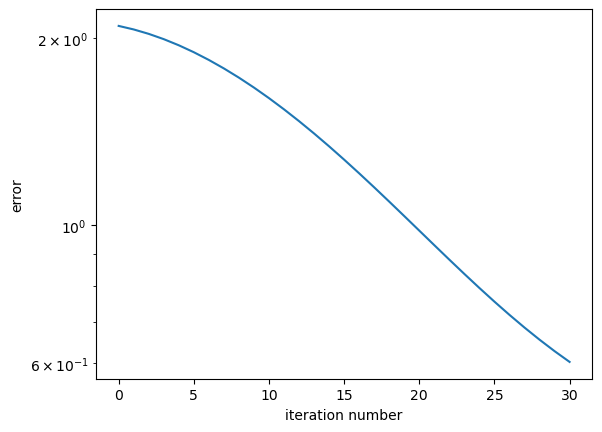

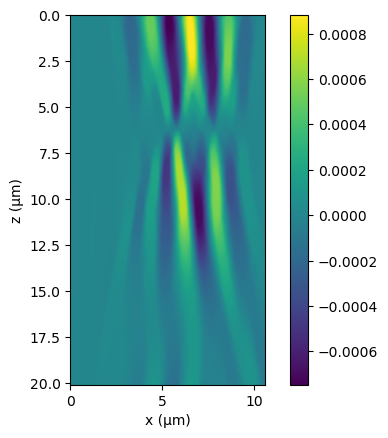

 13.888316 seconds (285.58 M allocations: 14.449 GiB, 13.37% gc time)


In [12]:
n0 = 1.52 # bulk refractive index
λ = 0.455 # illumination wavelength in µm
n_views = size(θ_l_i)
Lz = 20 # must be larger than the guide extent in z
nz = 300
dz = Lz/(nz-1)
Δsample = -6 # in µm
NA = 1.25 # numerical aperture of the microscope objective
nzk = 10
wg = Wg_bpm_ϕ(λ, n0, nx, nz, dx, dz, Δsample, NA, I_map_i, θ_l_i; nzk=nzk);
RI = zeros((nx,nz))
RI .= n0 # initialization to bulk RI
∇RI = similar(RI)
nZk = size(wg.Zkv,3)
Zkv = zeros(nZk)
∇Zkv = similar(Zkv)
∇Zkv .= 0
TV_prox! = get_FTV_prox!(RI, 2e-6, n_iter=10)
L = 5e5 # Lipschitz constant for RI reconstruction.
RI_method = Fista(RI, L) # optimization method for RI reconstruction.
LZk = 5e3 # Lipschitz constant for aberration reconstruction.
Zkv_method = Fista(Zkv, LZk) # optimization method for aberration reconstruction.
methods = (RI_method, Zkv_method);

ProgressMeter.ijulia_behavior(:clear)
errors = []
@time proximal_iter!((RI,Zkv), (∇RI,∇Zkv),
                     wg,
                     compute_fwd_wg_Zk!,
                     compute_err_wg!,
                     compute_grad_wg_Zk!,
                     methods,
                     30;
                     prox! = (TV_prox!, identity),
                     errors=errors, restart=true);

figure()
semilogy(errors)
xlabel("iteration number")
ylabel("error")
display(gcf())

ncut = 550 # we cut the x dimension for better visualization
dn = (RI_method.xk .- n0)[:,end:-1:1] # we subtract the bulk RI and recover the proper orientation
dn_cut = dn[(1+ncut):(end-ncut),:]'

figure()
imshow(dn_cut, extent=[0, (nx-2*ncut)*dx, nz*dz, 0])
colorbar()
ylabel("z (µm)")
xlabel("x (µm)")
display(gcf())

Progress:   1%|█                                        |  ETA: 0:01:29
Progress:   2%|█                                        |  ETA: 0:01:29
Progress:   2%|█                                        |  ETA: 0:01:27
Progress:   2%|██                                       |  ETA: 0:01:26
Progress:   3%|██                                       |  ETA: 0:01:26
Progress:   4%|██                                       |  ETA: 0:01:26
Progress:   4%|██                                       |  ETA: 0:01:26
Progress:   4%|██                                       |  ETA: 0:01:25
Progress:   5%|███                                      |  ETA: 0:01:24
Progress:   6%|███                                      |  ETA: 0:01:24
Progress:   6%|███                                      |  ETA: 0:01:25
Progress:   6%|███                                      |  ETA: 0:01:25
Progress:   7%|███                                      |  ETA: 0:01:24
Progress:   8%|████                                     |  ETA: 

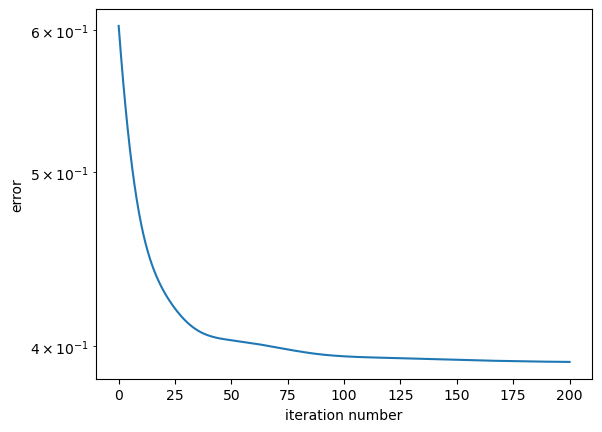

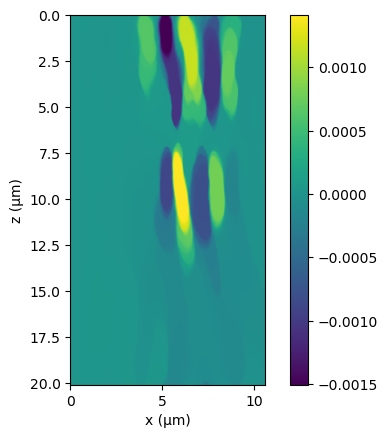

 89.867495 seconds (1.90 G allocations: 96.318 GiB, 11.30% gc time)


In [13]:
# We perform a few hundreds more iterations.

errors = []
@time proximal_iter!((RI,Zkv), (∇RI,∇Zkv),
                     wg,
                     compute_fwd_wg_Zk!,
                     compute_err_wg!,
                     compute_grad_wg_Zk!,
                     methods,
                     200;
                     prox! = (TV_prox!, identity),
                     errors=errors, restart=true);

figure()
semilogy(errors)
xlabel("iteration number")
ylabel("error")
display(gcf())


dn = (RI_method.xk .- n0)[:,end:-1:1]
dn_cut = dn[(1+ncut):(end-ncut),:]'

figure()
imshow(dn_cut, extent=[0, (nx-2*ncut)*dx, nz*dz, 0])
colorbar()
ylabel("z (µm)")
xlabel("x (µm)")
display(gcf())

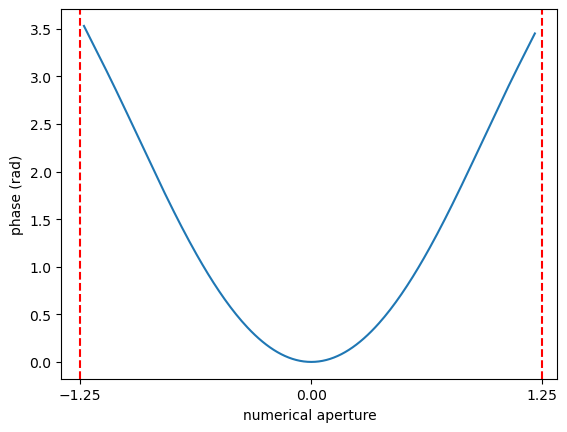

In [14]:

# We can also visualize the aberration radial profile.

NA_v, aberr = get_aberration(wg, Zkv)
nfcut = 600

figure()
plot(NA_v[nfcut:end-nfcut], aberr[nfcut:end-nfcut])
axvline(x=NA, ls="--", color="red")
axvline(x=-NA, ls="--", color="red")
xlabel("numerical aperture")
ylabel("phase (rad)")
xticks([-NA, 0, NA])
gcf()